# LIVER CANCER PREDICTION PROJECT

### Medical Disclaimer
This project is for educational purposes only. It is not a medical device, and its predictions should not be used for real clinical decisions. The model has not been validated on external datasets, and no regulatory approvals have been obtained.

### 1. Data Loading and Inspection

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report, accuracy_score, confusion_matrix,
    ConfusionMatrixDisplay, roc_auc_score, roc_curve
)

df = pd.read_csv('liver_cancer_dataset.csv')  # Load the dataset
df.head()

,age,gender,alcohol_use,hepatitis_b,hepatitis_c,cirrhosis,jaundice,abdominal_pain,weight_loss,fatigue,fever,ascites,edema,bilirubin,alt,ast,platelets,has_liver_cancer
0,24,Female,0,0,0,0,0,0,0,0,0,0,0,1.138435,37.765538,8.000000,205.449625,False
1,73,Male,0,0,0,0,0,1,0,1,1,0,0,0.417305,36.978344,91.054526,84.733489,True
2,65,Female,0,0,0,1,0,0,1,0,0,0,0,1.467329,34.732010,19.124257,156.559604,True
3,49,Female,0,0,0,0,0,1,0,0,1,0,0,1.236273,78.003323,106.020979,291.493777,True
4,49,Male,0,0,0,0,0,0,0,0,0,0,1,0.925122,67.930272,23.233036,184.226111,True


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 18 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   age               4000 non-null   int64  
 1   gender            4000 non-null   str    
 2   alcohol_use       4000 non-null   int64  
 3   hepatitis_b       4000 non-null   int64  
 4   hepatitis_c       4000 non-null   int64  
 5   cirrhosis         4000 non-null   int64  
 6   jaundice          4000 non-null   int64  
 7   abdominal_pain    4000 non-null   int64  
 8   weight_loss       4000 non-null   int64  
 9   fatigue           4000 non-null   int64  
 10  fever             4000 non-null   int64  
 11  ascites           4000 non-null   int64  
 12  edema             4000 non-null   int64  
 13  bilirubin         4000 non-null   float64
 14  alt               4000 non-null   float64
 15  ast               4000 non-null   float64
 16  platelets         4000 non-null   float64
 17  has_li

In [4]:
df.describe()

,age,alcohol_use,hepatitis_b,hepatitis_c,cirrhosis,jaundice,abdominal_pain,weight_loss,fatigue,fever,ascites,edema,bilirubin,alt,ast,platelets
count,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000
mean,53.585250,0.296750,0.095250,0.158750,0.103250,0.197250,0.250500,0.276500,0.347000,0.237750,0.083750,0.100750,1.155268,45.373515,51.920026,251.135656
std,20.786552,0.456883,0.293597,0.365488,0.304323,0.397972,0.433355,0.447323,0.476075,0.425758,0.277047,0.301035,0.705078,27.475059,31.947064,90.185781
min,18.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.200000,5.000000,8.000000,50.000000
25%,35.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.594935,23.564180,26.451189,187.467514
50%,53.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.101233,44.243166,49.481934,251.153431
75%,72.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,1.614100,64.420512,73.238241,313.573138
max,89.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,4.084206,157.788444,196.488733,566.385375


In [5]:
# Check for missing values
df.isnull().sum()

age                 0
gender              0
alcohol_use         0
hepatitis_b         0
hepatitis_c         0
cirrhosis           0
jaundice            0
abdominal_pain      0
weight_loss         0
fatigue             0
fever               0
ascites             0
edema               0
bilirubin           0
alt                 0
ast                 0
platelets           0
has_liver_cancer    0
dtype: int64

If missing values are found above, handle them before proceeding (e.g. `df.dropna()` or `df.fillna(...)`, depending on the feature).

### 2. Data Processing

In [6]:
# Inspect raw category values before mapping, to catch typos/unexpected labels
df['gender'].unique()

<StringArray>
['Female', 'Male']
Length: 2, dtype: str

In [7]:
df['gender'] = df['gender'].map({'Male': 1, 'Female': 0})  # Encode gender as a binary variable

# Confirm the mapping didn't introduce NaNs (i.e. no unexpected category values)
assert df['gender'].isnull().sum() == 0, "Unmapped gender values found"

### 3. Exploratory Data Analysis (EDA)

In [8]:
# Class balance — important to check before trusting accuracy as a metric
df['has_liver_cancer'].value_counts(normalize=True)

has_liver_cancer
True     0.97425
False    0.02575
Name: proportion, dtype: float64

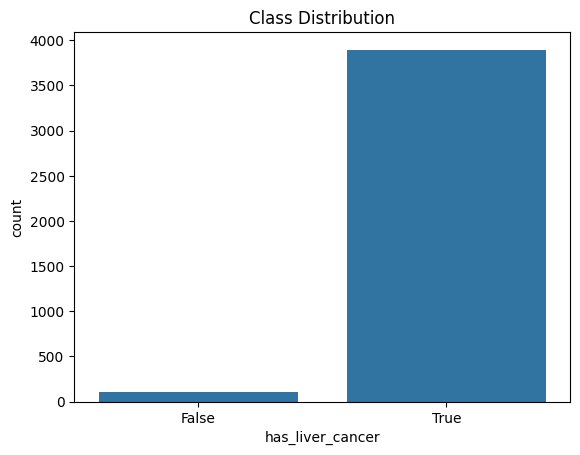

In [9]:
sns.countplot(x='has_liver_cancer', data=df)
plt.title('Class Distribution')
plt.show()

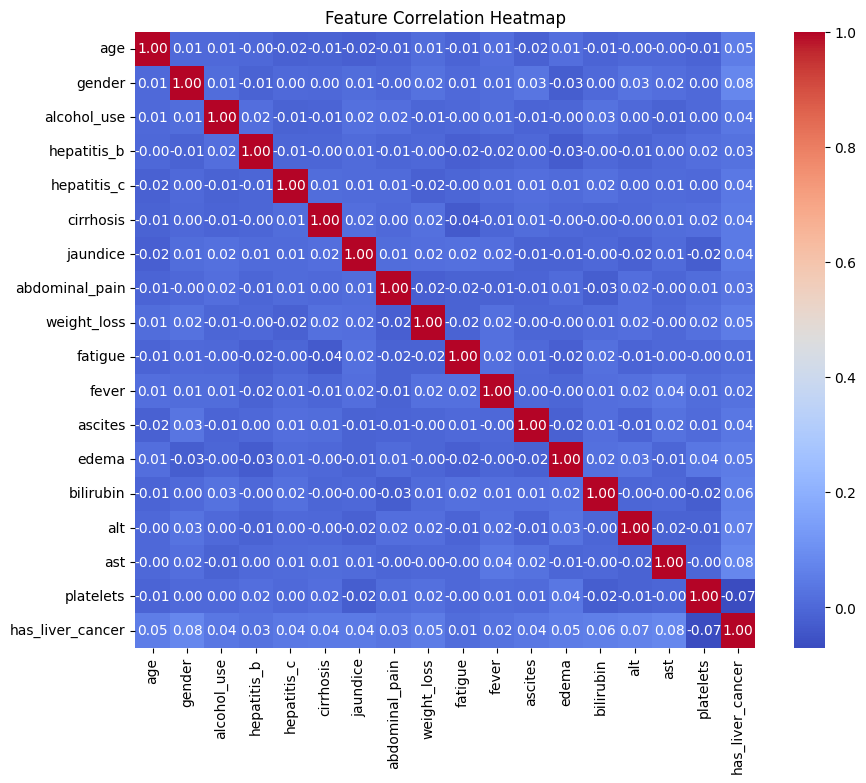

In [10]:
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Feature Correlation Heatmap')
plt.show()

In [11]:
X = df.drop('has_liver_cancer', axis=1)
y = df['has_liver_cancer']

### 4. Model Training (Logistic Regression)

In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=45, stratify=y
)  # stratify=y keeps class balance consistent across train/test splits

# Scale features so coefficients are comparable and the model converges reliably
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [13]:
model = LogisticRegression(max_iter=1000)
model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)
y_proba = model.predict_proba(X_test_scaled)[:, 1]

### 5. Model Evaluation and Results

In [20]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print()
print(classification_report(y_test, y_pred))

Accuracy: 0.975

              precision    recall  f1-score   support

       False       1.00      0.05      0.09        21
        True       0.97      1.00      0.99       779

    accuracy                           0.97       800
   macro avg       0.99      0.52      0.54       800
weighted avg       0.98      0.97      0.96       800



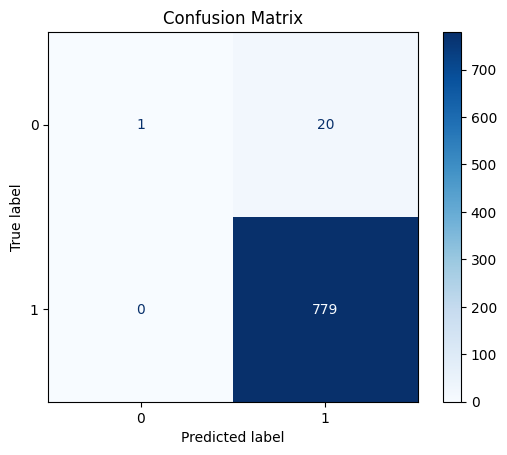

In [15]:
cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm).plot(cmap='Blues')
plt.title('Confusion Matrix')
plt.show()

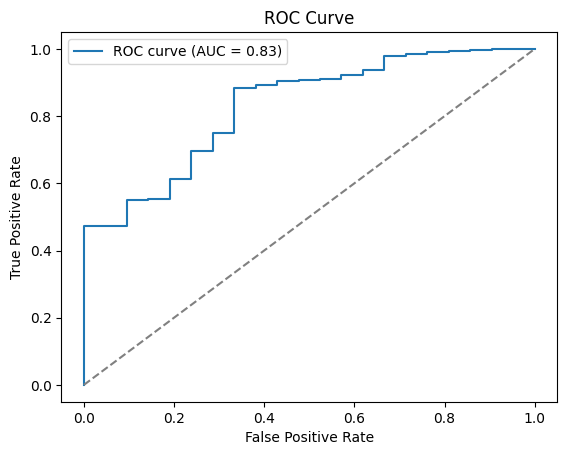

ROC-AUC: 0.8290849073904273


In [16]:
auc = roc_auc_score(y_test, y_proba)
fpr, tpr, _ = roc_curve(y_test, y_proba)

plt.plot(fpr, tpr, label=f'ROC curve (AUC = {auc:.2f})')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()

print("ROC-AUC:", auc)

### 6. Feature Importance Interpretation

In [ ]:
# Coefficients are now meaningful for comparison since features were scaled
coefficients = pd.DataFrame({
    'Feature': X.columns, 'Coefficient': model.coef_[0]
}).sort_values(by='Coefficient', ascending=False)

print(coefficients)

           Feature  Coefficient
12           edema     0.674295
15             ast     0.613466
11         ascites     0.526950
14             alt     0.522665
5        cirrhosis     0.447788
1           gender     0.407106
2      alcohol_use     0.391832
4      hepatitis_c     0.375812
13       bilirubin     0.371707
0              age     0.347826
8      weight_loss     0.343832
6         jaundice     0.297801
3      hepatitis_b     0.284170
7   abdominal_pain     0.252979
9          fatigue     0.155269
10           fever     0.118357
16       platelets    -0.474857


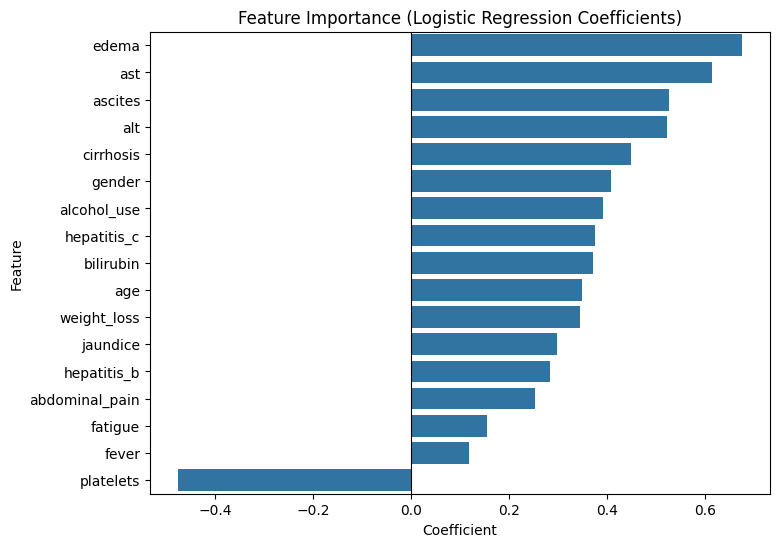

In [18]:
plt.figure(figsize=(8, 6))
sns.barplot(data=coefficients, x='Coefficient', y='Feature')
plt.title('Feature Importance (Logistic Regression Coefficients)')
plt.axvline(0, color='black', linewidth=0.8)
plt.show()

### 7. Save Model

In [19]:
Path('models').mkdir(exist_ok=True)
joblib.dump(model, 'models/logistic_model.pkl')
joblib.dump(scaler, 'models/scaler.pkl')
print("Model and scaler saved to models/")

Model and scaler saved to models/
